<h1 align="center"><font color="gree">CNN with TensorFlow</font></h1>

<font color="pink">Senior Data Scientist.: Dr. Eddy Giusepe Chirinos Isidro</font>

In [1]:
import ctypes
import glob
import os
import site

_base = os.path.join(site.getsitepackages()[0], "nvidia")
_so_files = []
for _pkg in sorted(os.listdir(_base)):
    if _pkg == "cu13":  # ignora libs CUDA 13 do torch
        continue
    _lib_dir = os.path.join(_base, _pkg, "lib")
    if os.path.isdir(_lib_dir):
        for _so in glob.glob(os.path.join(_lib_dir, "lib*.so.*")):
            _ver = os.path.basename(_so).split(".so.")[-1]
            if _ver.isdigit():  # ex.: libcublas.so.12 (nao libcublas.so.12.1.0)
                _so_files.append(_so)

_pending = list(_so_files)
for _ in range(5):
    _still = []
    for _so in _pending:
        try:
            ctypes.CDLL(_so, mode=ctypes.RTLD_GLOBAL)
        except OSError:
            _still.append(_so)
    if _still == _pending:  # nenhum progresso nesta passada
        break
    _pending = _still
    if not _pending:
        break

print("CUDA libs pre-carregadas:", len(_so_files) - len(_pending), "/", len(_so_files))

CUDA libs pre-carregadas: 27 / 27


In [2]:
import tensorflow as tf
from tensorflow import keras
from keras import layers, models
import matplotlib.pyplot as plt
import numpy as np


print("Version of TensorFlow:", tf.__version__)


I0000 00:00:1786160077.855141  129212 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1786160077.885343  129212 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI AVX_VNNI_INT8 AVX_NE_CONVERT FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1786160078.354142  129212 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Version of TensorFlow: 2.21.0


In [3]:
device_name = tf.test.gpu_device_name()
if device_name != '/device:GPU:0':
    print('Warning: No GPU detected')
else:
    print('GPU detected:', device_name)

GPU detected: /device:GPU:0


W0000 00:00:1786160078.756178  129212 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
I0000 00:00:1786160078.854127  129212 gpu_device.cc:2043] Created device /device:GPU:0 with 9722 MB memory:  -> device: 0, name: NVIDIA RTX PRO 3000 Blackwell Generation Laptop GPU, pci bus id: 0000:02:00.0, compute capability: 12.0a


In [4]:
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print('GPU detectada:', gpus)
else:
    print('Aviso: nenhuma GPU detectada — usando CPU')

GPU detectada: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


W0000 00:00:1786160079.389091  129212 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.


In [5]:
import torch

print(torch.__version__)

2.13.0+cu130


## <font color="gree">Dataset</font>

In [6]:
# Use the dataset CIFAR-10:
# The dataset CIFAR-10 contains Images a color (32x32 pixels, 3 channels). Also, it has 10 classes.
from keras.datasets import cifar10


(x_train, y_train), (x_test, y_test) = cifar10.load_data()

print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)


(50000, 32, 32, 3)
(50000, 1)
(10000, 32, 32, 3)
(10000, 1)


In [7]:
# Name of the 10 classes.
#class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
class_name = ['Avión', 'Auto', 'Pajaro', 'Gato', 'Ciervo', 'Perro', 'Rana', 'Caballo', 'Barco', 'Camión']

# Normalize the values of the pixels to be between 0 and 1:
x_train, x_test = x_train / 255.0, x_test / 255.0

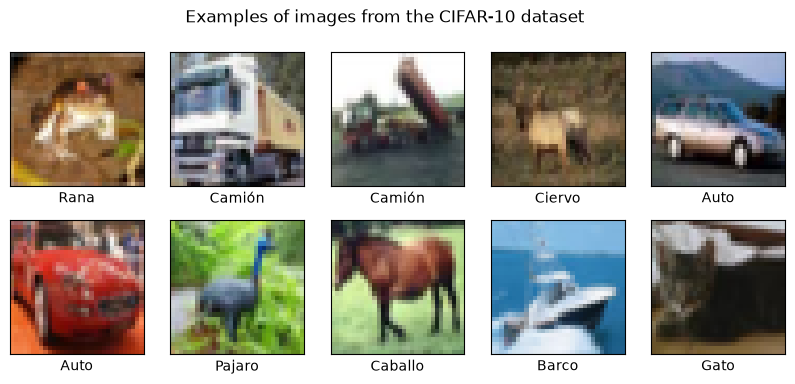

In [8]:
# Visualization some images:
plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(x_train[i], cmap=plt.cm.binary)
    plt.xlabel(class_name[y_train[i][0]])
plt.suptitle("Examples of images from the CIFAR-10 dataset")
plt.show()

## <font color="gree">Convolutional Neural Network (CNN) Architecture</font>

In [9]:
# Explicação dos blocos:
# Conv2D: aplica filtros (detectores de características como bordas, texturas, etc.)
# MaxPooling2D: reduz a dimensão espacial (largura e altura) da saída, mantendo as características mais importantes.
# Flatten: transforma a saída em um vetor unidimensional.
# Dense: camadas totalmente conectadas para classificar segun las caracteristicas extraidas
# Dropout: reduz el overfitting

# Criação do modelo CNN:
model = models.Sequential([
    # Bloco 1: Extração de caracteristicas de baixo nível (bordes, curvas, etc.)
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
    layers.MaxPooling2D((2, 2)),

    # Bloco 2: Extração de padrões mais complexos (texturas, formas, etc.)
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Bloco 3: Combinação de padrões avançados (objetos, partes, etc.)
    layers.Conv2D(64, (3, 3), activation='relu'),

    # Classificador: Camada totalmente conectada para classificar las caracteristicas extraidas
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10) # Uma por cada clase
])

# Mostramos el resumen de la arquitectura e a quantidade de parametros:
model.summary()


/home/eddygiusepe/1_GitHub/Understanding_Convolutional_Neural_Networks_CNN/.venv/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
W0000 00:00:1786160093.516455  129212 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
I0000 00:00:1786160093.529198  129212 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9722 MB memory:  -> device: 0, name: NVIDIA RTX PRO 3000 Blackwell Generation Laptop GPU, pci bus id: 0000:02:00.0, compute capability: 12.0a


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122,570 (478.79 KB)

 Trainable params: 122,570 (478.79 KB)

 Non-trainable params: 0 (0.00 B)

## <font color="gree">Training the model</font>

In [12]:
# Compilamos el modelo:
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

# Entrenamos el modelo por 10 epochs:
history = model.fit(x_train, y_train,
                    epochs=40,
                    validation_data=(x_test, y_test))



Epoch 1/40


I0000 00:00:1786160224.050174  129355 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_154600__.29


1544/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8441 - loss: 0.4364

I0000 00:00:1786160227.324216  129357 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_154600__.29


1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8438 - loss: 0.4369 - val_accuracy: 0.7064 - val_loss: 1.0401
Epoch 2/40
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8504 - loss: 0.4155 - val_accuracy: 0.6988 - val_loss: 1.0783
Epoch 3/40
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8549 - loss: 0.3973 - val_accuracy: 0.6914 - val_loss: 1.1566
Epoch 4/40
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8606 - loss: 0.3855 - val_accuracy: 0.6954 - val_loss: 1.1426
Epoch 5/40
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8664 - loss: 0.3690 - val_accuracy: 0.7006 - val_loss: 1.1705
Epoch 6/40
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8707 - loss: 0.3555 - val_accuracy: 0.6989 - val_loss: 1.2196
Epoch 7/40
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8761 - loss: 0.3419 - val_accuracy: 0.6927 - val_loss: 1.2653
Epoch 8/40
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8814 - loss: 0.3287 - val_accurac

## <font color="gree">Evaluating the model</font>

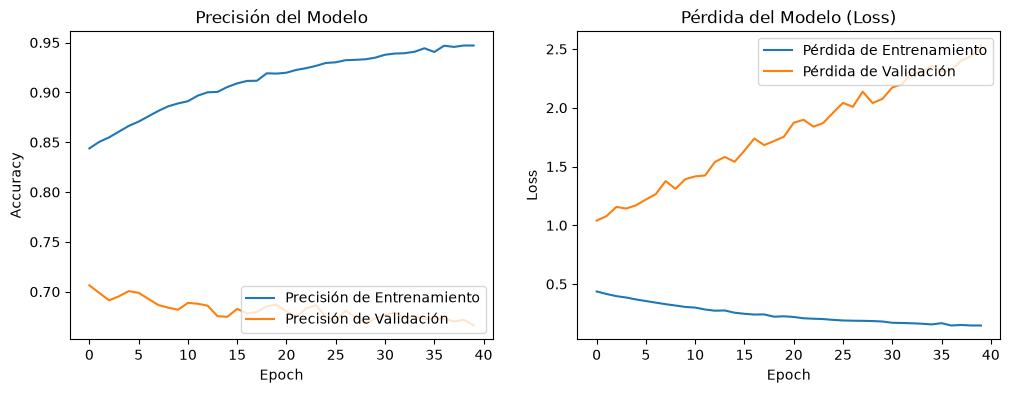

In [13]:
# Graficamos la precisión y la pérdida del modelo:
plt.figure(figsize=(12, 4))

# Graficamos la precisión:
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Precisión de Entrenamiento')
plt.plot(history.history['val_accuracy'], label='Precisión de Validación')
plt.title('Precisión del Modelo')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')


plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Pérdida de Entrenamiento')
plt.plot(history.history['val_loss'], label='Pérdida de Validación')
plt.title('Pérdida del Modelo (Loss)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')

plt.show()
